In [1]:
!pip -q install nltk

import copy
import io
import json
import math
import os
import random
import re
import time
import unicodedata
import warnings

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from nltk.translate.bleu_score import (
    SmoothingFunction,
    corpus_bleu,
    sentence_bleu
)

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
SEED = 42
SPLIT_SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("A GPU is strongly recommended for the eight experiments.")

Device: cuda
GPU: Tesla T4


In [3]:
from google.colab import files

uploaded = files.upload()
DATA_FILE = list(uploaded.keys())[0]

print("Dataset file:", DATA_FILE)

Saving vast_english_french.txt to vast_english_french.txt
Dataset file: vast_english_french.txt


In [4]:
def normalize_text(text):
    text = unicodedata.normalize("NFKC", str(text))
    text = text.strip()
    text = re.sub(r"\s+", " ", text)

    return text


def load_translation_pairs(file_path):
    sentence_pairs = []

    with open(
        file_path,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as file:

        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            if "\t" in line:
                parts = line.split("\t")

            elif "|||" in line:
                parts = line.split("|||")

            else:
                continue

            if len(parts) < 2:
                continue

            english_sentence = normalize_text(parts[0])
            french_sentence = normalize_text(parts[1])

            if english_sentence and french_sentence:
                sentence_pairs.append(
                    (english_sentence, french_sentence)
                )

    return sentence_pairs


all_pairs = load_translation_pairs(DATA_FILE)

print("Number of sentence pairs:", len(all_pairs))

if len(all_pairs) == 0:
    raise ValueError(
        "No sentence pairs were detected. Inspect the file and "
        "verify the delimiter between English and French."
    )

print("\nFirst five pairs:\n")

for english, french in all_pairs[:5]:
    print("English:", english)
    print("French: ", french)
    print()

Number of sentence pairs: 555

First five pairs:

English: I am cold
French:  J'ai froid

English: You are tired
French:  Tu es fatigué

English: He is hungry
French:  Il a faim

English: She is happy
French:  Elle est heureuse

English: We are friends
French:  Nous sommes amis



In [5]:
QUICK_TEST = False

if QUICK_TEST:
    all_pairs = all_pairs[:5000]
    print("Quick-test mode: using", len(all_pairs), "pairs")
else:
    print("Final mode: using all", len(all_pairs), "pairs")

Final mode: using all 555 pairs


In [6]:
all_indices = np.arange(len(all_pairs))

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=0.20,
    random_state=SPLIT_SEED,
    shuffle=True
)

train_pairs = [
    all_pairs[index]
    for index in train_indices
]

validation_pairs = [
    all_pairs[index]
    for index in validation_indices
]

np.save(
    "homework4_train_indices.npy",
    train_indices
)

np.save(
    "homework4_validation_indices.npy",
    validation_indices
)

print("Total pairs:", len(all_pairs))
print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(validation_pairs))

print(
    "Training percentage:",
    100 * len(train_pairs) / len(all_pairs)
)

print(
    "Validation percentage:",
    100 * len(validation_pairs) / len(all_pairs)
)

Total pairs: 555
Training pairs: 444
Validation pairs: 111
Training percentage: 80.0
Validation percentage: 20.0


In [7]:
LOWERCASE = True

TOKEN_PATTERN = re.compile(
    r"[^\W_]+(?:['’-][^\W_]+)*|[^\w\s]",
    flags=re.UNICODE
)


def tokenize(sentence):
    sentence = normalize_text(sentence)

    if LOWERCASE:
        sentence = sentence.lower()

    return TOKEN_PATTERN.findall(sentence)


def detokenize(tokens):
    text = " ".join(tokens)

    # Remove spaces before punctuation.
    text = re.sub(
        r"\s+([.,!?;:%\)\]\}])",
        r"\1",
        text
    )

    # Remove spaces after opening punctuation.
    text = re.sub(
        r"([\(\[\{])\s+",
        r"\1",
        text
    )

    # Rejoin apostrophes.
    text = text.replace(" ' ", "'")
    text = text.replace(" ’ ", "’")

    return text


example_english = train_pairs[0][0]
example_french = train_pairs[0][1]

print("English tokens:")
print(tokenize(example_english))

print("\nFrench tokens:")
print(tokenize(example_french))

English tokens:
['they', 'practice', 'piano', 'every', 'afternoon']

French tokens:
['ils', 'pratiquent', 'le', 'piano', 'tous', 'les', 'après-midi']


In [8]:
PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"

SPECIAL_TOKENS = [
    PAD_TOKEN,
    UNK_TOKEN,
    BOS_TOKEN,
    EOS_TOKEN
]

MIN_FREQUENCY = 1
MAX_ENGLISH_VOCABULARY = 50000
MAX_FRENCH_VOCABULARY = 50000


def build_vocabulary(
    sentences,
    minimum_frequency=2,
    maximum_size=20000
):
    token_counter = Counter()

    for sentence in sentences:
        token_counter.update(
            tokenize(sentence)
        )

    vocabulary_tokens = [
        token
        for token, frequency in token_counter.most_common()
        if frequency >= minimum_frequency
    ]

    if maximum_size is not None:
        available_positions = (
            maximum_size - len(SPECIAL_TOKENS)
        )

        vocabulary_tokens = vocabulary_tokens[
            :available_positions
        ]

    index_to_token = (
        SPECIAL_TOKENS + vocabulary_tokens
    )

    token_to_index = {
        token: index
        for index, token in enumerate(index_to_token)
    }

    return token_to_index, index_to_token


training_english_sentences = [
    english
    for english, french in train_pairs
]

training_french_sentences = [
    french
    for english, french in train_pairs
]

english_token_to_index, english_index_to_token = (
    build_vocabulary(
        training_english_sentences,
        minimum_frequency=MIN_FREQUENCY,
        maximum_size=MAX_ENGLISH_VOCABULARY
    )
)

french_token_to_index, french_index_to_token = (
    build_vocabulary(
        training_french_sentences,
        minimum_frequency=MIN_FREQUENCY,
        maximum_size=MAX_FRENCH_VOCABULARY
    )
)

ENGLISH_VOCABULARY_SIZE = len(
    english_index_to_token
)

FRENCH_VOCABULARY_SIZE = len(
    french_index_to_token
)

ENGLISH_PAD_INDEX = english_token_to_index[PAD_TOKEN]
ENGLISH_UNK_INDEX = english_token_to_index[UNK_TOKEN]
ENGLISH_BOS_INDEX = english_token_to_index[BOS_TOKEN]
ENGLISH_EOS_INDEX = english_token_to_index[EOS_TOKEN]

FRENCH_PAD_INDEX = french_token_to_index[PAD_TOKEN]
FRENCH_UNK_INDEX = french_token_to_index[UNK_TOKEN]
FRENCH_BOS_INDEX = french_token_to_index[BOS_TOKEN]
FRENCH_EOS_INDEX = french_token_to_index[EOS_TOKEN]

print(
    "English vocabulary size:",
    ENGLISH_VOCABULARY_SIZE
)

print(
    "French vocabulary size:",
    FRENCH_VOCABULARY_SIZE
)

English vocabulary size: 894
French vocabulary size: 994


In [9]:
english_training_lengths = [
    len(tokenize(english)) + 2
    for english, french in train_pairs
]

french_training_lengths = [
    len(tokenize(french)) + 2
    for english, french in train_pairs
]

MAX_ENGLISH_LENGTH = int(
    np.percentile(
        english_training_lengths,
        95
    )
)

MAX_FRENCH_LENGTH = int(
    np.percentile(
        french_training_lengths,
        95
    )
)

# Apply reasonable limits for Colab memory.
MAX_ENGLISH_LENGTH = min(
    max(MAX_ENGLISH_LENGTH, 10),
    40
)

MAX_FRENCH_LENGTH = min(
    max(MAX_FRENCH_LENGTH, 10),
    45
)

print("Maximum English length:", MAX_ENGLISH_LENGTH)
print("Maximum French length:", MAX_FRENCH_LENGTH)

Maximum English length: 11
Maximum French length: 12


In [10]:
def encode_sentence(
    sentence,
    token_to_index,
    maximum_length
):
    unknown_index = token_to_index[UNK_TOKEN]
    beginning_index = token_to_index[BOS_TOKEN]
    ending_index = token_to_index[EOS_TOKEN]
    padding_index = token_to_index[PAD_TOKEN]

    sentence_tokens = tokenize(sentence)

    token_indices = [
        token_to_index.get(
            token,
            unknown_index
        )
        for token in sentence_tokens
    ]

    # Reserve positions for BOS and EOS.
    token_indices = token_indices[
        :maximum_length - 2
    ]

    encoded = (
        [beginning_index]
        + token_indices
        + [ending_index]
    )

    padding_needed = (
        maximum_length - len(encoded)
    )

    encoded += [
        padding_index
    ] * padding_needed

    return encoded


def encode_sentence_pairs(sentence_pairs):
    english_encoded = []
    french_encoded = []

    for english_sentence, french_sentence in sentence_pairs:
        english_encoded.append(
            encode_sentence(
                english_sentence,
                english_token_to_index,
                MAX_ENGLISH_LENGTH
            )
        )

        french_encoded.append(
            encode_sentence(
                french_sentence,
                french_token_to_index,
                MAX_FRENCH_LENGTH
            )
        )

    english_tensor = torch.tensor(
        english_encoded,
        dtype=torch.long
    )

    french_tensor = torch.tensor(
        french_encoded,
        dtype=torch.long
    )

    return english_tensor, french_tensor

In [11]:
train_english_tensor, train_french_tensor = (
    encode_sentence_pairs(train_pairs)
)

validation_english_tensor, validation_french_tensor = (
    encode_sentence_pairs(validation_pairs)
)

print(
    "Training English tensor:",
    train_english_tensor.shape
)

print(
    "Training French tensor:",
    train_french_tensor.shape
)

print(
    "Validation English tensor:",
    validation_english_tensor.shape
)

print(
    "Validation French tensor:",
    validation_french_tensor.shape
)

Training English tensor: torch.Size([444, 11])
Training French tensor: torch.Size([444, 12])
Validation English tensor: torch.Size([111, 11])
Validation French tensor: torch.Size([111, 12])


In [12]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    train_english_tensor,
    train_french_tensor
)

validation_dataset = TensorDataset(
    validation_english_tensor,
    validation_french_tensor
)

training_generator = torch.Generator()
training_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=training_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))

Training batches: 7
Validation batches: 2


In [13]:
def decode_indices(
    indices,
    index_to_token,
    stop_at_eos=True
):
    decoded_tokens = []

    for index in indices:
        index = int(index)

        token = index_to_token[index]

        if token == EOS_TOKEN and stop_at_eos:
            break

        if token not in {
            PAD_TOKEN,
            BOS_TOKEN,
            EOS_TOKEN
        }:
            decoded_tokens.append(token)

    return detokenize(decoded_tokens)


example_source, example_target = train_dataset[0]

print(
    "Decoded English:",
    decode_indices(
        example_source,
        english_index_to_token
    )
)

print(
    "Decoded French:",
    decode_indices(
        example_target,
        french_index_to_token
    )
)

Decoded English: they practice piano every afternoon
Decoded French: ils pratiquent le piano tous les après-midi


In [14]:
class SinusoidalPositionalEncoding(nn.Module):
    def __init__(
        self,
        d_model,
        maximum_length,
        dropout=0.10
    ):
        super().__init__()

        self.dropout = nn.Dropout(dropout)

        positional_encoding = torch.zeros(
            maximum_length,
            d_model
        )

        positions = torch.arange(
            0,
            maximum_length,
            dtype=torch.float
        ).unsqueeze(1)

        division_terms = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            ).float()
            * (
                -math.log(10000.0)
                / d_model
            )
        )

        positional_encoding[:, 0::2] = torch.sin(
            positions * division_terms
        )

        positional_encoding[:, 1::2] = torch.cos(
            positions * division_terms
        )

        positional_encoding = positional_encoding.unsqueeze(0)

        self.register_buffer(
            "positional_encoding",
            positional_encoding
        )

    def forward(self, embedded_tokens):
        sequence_length = embedded_tokens.size(1)

        embedded_tokens = (
            embedded_tokens
            + self.positional_encoding[
                :,
                :sequence_length,
                :
            ]
        )

        return self.dropout(embedded_tokens)

In [15]:
class TranslationTransformer(nn.Module):
    def __init__(
        self,
        source_vocabulary_size,
        target_vocabulary_size,
        source_padding_index,
        target_padding_index,
        d_model=128,
        number_of_heads=2,
        number_of_layers=2,
        feedforward_size=512,
        dropout=0.10,
        maximum_source_length=40,
        maximum_target_length=45
    ):
        super().__init__()

        if d_model % number_of_heads != 0:
            raise ValueError(
                "d_model must be divisible by number_of_heads."
            )

        self.d_model = d_model
        self.number_of_heads = number_of_heads
        self.number_of_layers = number_of_layers
        self.feedforward_size = feedforward_size

        self.source_padding_index = (
            source_padding_index
        )

        self.target_padding_index = (
            target_padding_index
        )

        self.source_embedding = nn.Embedding(
            source_vocabulary_size,
            d_model,
            padding_idx=source_padding_index
        )

        self.target_embedding = nn.Embedding(
            target_vocabulary_size,
            d_model,
            padding_idx=target_padding_index
        )

        self.source_positional_encoding = (
            SinusoidalPositionalEncoding(
                d_model=d_model,
                maximum_length=maximum_source_length,
                dropout=dropout
            )
        )

        self.target_positional_encoding = (
            SinusoidalPositionalEncoding(
                d_model=d_model,
                maximum_length=maximum_target_length,
                dropout=dropout
            )
        )

        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=number_of_heads,
            num_encoder_layers=number_of_layers,
            num_decoder_layers=number_of_layers,
            dim_feedforward=feedforward_size,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.output_layer = nn.Linear(
            d_model,
            target_vocabulary_size
        )

    def create_target_causal_mask(
        self,
        target_length,
        target_device
    ):
        return torch.triu(
            torch.ones(
                target_length,
                target_length,
                dtype=torch.bool,
                device=target_device
            ),
            diagonal=1
        )

    def forward(
        self,
        source_tokens,
        target_input_tokens
    ):
        source_padding_mask = source_tokens.eq(
            self.source_padding_index
        )

        target_padding_mask = target_input_tokens.eq(
            self.target_padding_index
        )

        target_causal_mask = (
            self.create_target_causal_mask(
                target_input_tokens.size(1),
                target_input_tokens.device
            )
        )

        source_embeddings = (
            self.source_embedding(source_tokens)
            * math.sqrt(self.d_model)
        )

        target_embeddings = (
            self.target_embedding(
                target_input_tokens
            )
            * math.sqrt(self.d_model)
        )

        source_embeddings = (
            self.source_positional_encoding(
                source_embeddings
            )
        )

        target_embeddings = (
            self.target_positional_encoding(
                target_embeddings
            )
        )

        transformer_output = self.transformer(
            src=source_embeddings,
            tgt=target_embeddings,
            tgt_mask=target_causal_mask,
            src_key_padding_mask=source_padding_mask,
            tgt_key_padding_mask=target_padding_mask,
            memory_key_padding_mask=source_padding_mask
        )

        logits = self.output_layer(
            transformer_output
        )

        return logits

In [16]:
test_model = TranslationTransformer(
    source_vocabulary_size=ENGLISH_VOCABULARY_SIZE,
    target_vocabulary_size=FRENCH_VOCABULARY_SIZE,
    source_padding_index=ENGLISH_PAD_INDEX,
    target_padding_index=FRENCH_PAD_INDEX,
    d_model=128,
    number_of_heads=2,
    number_of_layers=2,
    feedforward_size=512,
    maximum_source_length=MAX_ENGLISH_LENGTH,
    maximum_target_length=MAX_FRENCH_LENGTH
).to(device)

test_source, test_target = next(
    iter(train_loader)
)

test_source = test_source.to(device)
test_target = test_target.to(device)

test_target_input = test_target[:, :-1]

test_logits = test_model(
    test_source,
    test_target_input
)

print("Source shape:", test_source.shape)
print("Target input shape:", test_target_input.shape)
print("Output shape:", test_logits.shape)

expected_shape = (
    test_source.size(0),
    MAX_FRENCH_LENGTH - 1,
    FRENCH_VOCABULARY_SIZE
)

assert test_logits.shape == expected_shape

print("Transformer test passed.")

Source shape: torch.Size([64, 11])
Target input shape: torch.Size([64, 11])
Output shape: torch.Size([64, 11, 994])
Transformer test passed.


In [17]:
def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )


def measure_model_size_megabytes(model):
    temporary_buffer = io.BytesIO()

    torch.save(
        model.state_dict(),
        temporary_buffer
    )

    size_bytes = temporary_buffer.getbuffer().nbytes

    return size_bytes / (1024 ** 2)


def synchronize_device():
    if torch.cuda.is_available():
        torch.cuda.synchronize()


print(
    "Test model parameters:",
    f"{count_trainable_parameters(test_model):,}"
)

print(
    "Test model size:",
    f"{measure_model_size_megabytes(test_model):.3f} MB"
)

del test_model

if torch.cuda.is_available():
    torch.cuda.empty_cache()

Test model parameters: 1,296,098
Test model size: 4.981 MB


In [18]:
@torch.no_grad()
def evaluate_validation_loss(
    model,
    data_loader,
    loss_function
):
    model.eval()

    total_loss = 0.0
    total_non_padding_tokens = 0

    for source_tokens, target_tokens in data_loader:
        source_tokens = source_tokens.to(
            device,
            non_blocking=True
        )

        target_tokens = target_tokens.to(
            device,
            non_blocking=True
        )

        target_input = target_tokens[:, :-1]
        target_expected = target_tokens[:, 1:]

        logits = model(
            source_tokens,
            target_input
        )

        loss = loss_function(
            logits.reshape(
                -1,
                FRENCH_VOCABULARY_SIZE
            ),
            target_expected.reshape(-1)
        )

        number_of_tokens = (
            target_expected
            .ne(FRENCH_PAD_INDEX)
            .sum()
            .item()
        )

        total_loss += (
            loss.item() * number_of_tokens
        )

        total_non_padding_tokens += number_of_tokens

    average_loss = (
        total_loss / total_non_padding_tokens
    )

    return average_loss

In [19]:
@torch.no_grad()
def greedy_decode_batch(
    model,
    source_tokens,
    maximum_target_length=MAX_FRENCH_LENGTH
):
    model.eval()

    batch_size = source_tokens.size(0)

    generated_tokens = torch.full(
        size=(batch_size, 1),
        fill_value=FRENCH_BOS_INDEX,
        dtype=torch.long,
        device=source_tokens.device
    )

    finished_sequences = torch.zeros(
        batch_size,
        dtype=torch.bool,
        device=source_tokens.device
    )

    for _ in range(maximum_target_length - 1):
        logits = model(
            source_tokens,
            generated_tokens
        )

        next_token = logits[
            :,
            -1,
            :
        ].argmax(dim=-1)

        next_token = torch.where(
            finished_sequences,
            torch.full_like(
                next_token,
                FRENCH_PAD_INDEX
            ),
            next_token
        )

        generated_tokens = torch.cat(
            [
                generated_tokens,
                next_token.unsqueeze(1)
            ],
            dim=1
        )

        finished_sequences = (
            finished_sequences
            | next_token.eq(FRENCH_EOS_INDEX)
        )

        if finished_sequences.all():
            break

    return generated_tokens

In [20]:
def clean_token_indices(
    token_indices,
    index_to_token
):
    cleaned_tokens = []

    for index in token_indices:
        index = int(index)

        token = index_to_token[index]

        if token == EOS_TOKEN:
            break

        if token not in {
            PAD_TOKEN,
            BOS_TOKEN,
            EOS_TOKEN
        }:
            cleaned_tokens.append(token)

    return cleaned_tokens


@torch.no_grad()
def evaluate_translation_metrics(
    model,
    data_loader,
    maximum_batches=None
):
    model.eval()

    references = []
    hypotheses = []

    exact_match_count = 0
    sentence_count = 0

    smoothing = SmoothingFunction().method1

    for batch_number, (
        source_tokens,
        target_tokens
    ) in enumerate(data_loader):

        if (
            maximum_batches is not None
            and batch_number >= maximum_batches
        ):
            break

        source_tokens = source_tokens.to(
            device,
            non_blocking=True
        )

        generated_tokens = greedy_decode_batch(
            model=model,
            source_tokens=source_tokens,
            maximum_target_length=MAX_FRENCH_LENGTH
        )

        generated_tokens = generated_tokens.cpu()
        target_tokens = target_tokens.cpu()

        for prediction, reference in zip(
            generated_tokens,
            target_tokens
        ):
            predicted_words = clean_token_indices(
                prediction,
                french_index_to_token
            )

            reference_words = clean_token_indices(
                reference,
                french_index_to_token
            )

            references.append(
                [reference_words]
            )

            hypotheses.append(
                predicted_words
            )

            if predicted_words == reference_words:
                exact_match_count += 1

            sentence_count += 1

    sequence_accuracy = (
        exact_match_count / sentence_count
        if sentence_count > 0
        else 0.0
    )

    bleu_4 = corpus_bleu(
        list_of_references=references,
        hypotheses=hypotheses,
        weights=(0.25, 0.25, 0.25, 0.25),
        smoothing_function=smoothing
    )

    return sequence_accuracy, bleu_4

In [21]:
if QUICK_TEST:
    NUMBER_OF_EPOCHS = 2
    METRIC_MAX_BATCHES = 10
else:
    NUMBER_OF_EPOCHS = 10

    # None evaluates the entire validation set.
    METRIC_MAX_BATCHES = None


LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.10
EARLY_STOPPING_PATIENCE = 3

print("Quick test:", QUICK_TEST)
print("Epochs:", NUMBER_OF_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Metric batch limit:", METRIC_MAX_BATCHES)

Quick test: False
Epochs: 10
Batch size: 64
Learning rate: 0.0003
Metric batch limit: None


In [22]:
QUICK_TEST = False
METRIC_MAX_BATCHES = None

In [23]:
def train_translation_experiment(
    experiment_name,
    d_model,
    number_of_heads,
    number_of_layers,
    feedforward_size
):
    print("\n" + "=" * 85)
    print("Experiment:", experiment_name)

    print(
        f"d_model={d_model}, "
        f"heads={number_of_heads}, "
        f"encoder blocks={number_of_layers}, "
        f"decoder blocks={number_of_layers}, "
        f"d_ff={feedforward_size}"
    )

    print("=" * 85)

    set_seed()

    model = TranslationTransformer(
        source_vocabulary_size=ENGLISH_VOCABULARY_SIZE,
        target_vocabulary_size=FRENCH_VOCABULARY_SIZE,
        source_padding_index=ENGLISH_PAD_INDEX,
        target_padding_index=FRENCH_PAD_INDEX,
        d_model=d_model,
        number_of_heads=number_of_heads,
        number_of_layers=number_of_layers,
        feedforward_size=feedforward_size,
        dropout=DROPOUT,
        maximum_source_length=MAX_ENGLISH_LENGTH,
        maximum_target_length=MAX_FRENCH_LENGTH
    ).to(device)

    loss_function = nn.CrossEntropyLoss(
        ignore_index=FRENCH_PAD_INDEX
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUMBER_OF_EPOCHS
    )

    mixed_precision_enabled = torch.cuda.is_available()

    scaler = torch.cuda.amp.GradScaler(
        enabled=mixed_precision_enabled
    )

    history = {
        "training_loss": [],
        "validation_loss": []
    }

    best_validation_loss = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0

    checkpoint_path = (
        f"problem3_{experiment_name}_best.pt"
    )

    synchronize_device()
    training_start_time = time.perf_counter()

    for epoch in range(
        1,
        NUMBER_OF_EPOCHS + 1
    ):
        model.train()

        total_training_loss = 0.0
        total_training_tokens = 0

        for source_tokens, target_tokens in train_loader:
            source_tokens = source_tokens.to(
                device,
                non_blocking=True
            )

            target_tokens = target_tokens.to(
                device,
                non_blocking=True
            )

            target_input = target_tokens[:, :-1]
            target_expected = target_tokens[:, 1:]

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(
                enabled=mixed_precision_enabled
            ):
                logits = model(
                    source_tokens,
                    target_input
                )

                loss = loss_function(
                    logits.reshape(
                        -1,
                        FRENCH_VOCABULARY_SIZE
                    ),
                    target_expected.reshape(-1)
                )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0
            )

            scaler.step(optimizer)
            scaler.update()

            number_of_tokens = (
                target_expected
                .ne(FRENCH_PAD_INDEX)
                .sum()
                .item()
            )

            total_training_loss += (
                loss.item() * number_of_tokens
            )

            total_training_tokens += number_of_tokens

        average_training_loss = (
            total_training_loss
            / total_training_tokens
        )

        validation_loss = evaluate_validation_loss(
            model,
            validation_loader,
            loss_function
        )

        history["training_loss"].append(
            average_training_loss
        )

        history["validation_loss"].append(
            validation_loss
        )

        scheduler.step()

        print(
            f"Epoch {epoch:2d}/{NUMBER_OF_EPOCHS} | "
            f"Train Loss: {average_training_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.6f}"
        )

        if validation_loss < best_validation_loss:
            best_validation_loss = validation_loss
            best_epoch = epoch
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):
            print(
                "Early stopping after",
                epoch,
                "epochs."
            )
            break

    synchronize_device()

    training_time_seconds = (
        time.perf_counter()
        - training_start_time
    )

    model.load_state_dict(
        torch.load(
            checkpoint_path,
            map_location=device
        )
    )

    final_validation_loss = (
        evaluate_validation_loss(
            model,
            validation_loader,
            loss_function
        )
    )

    (
        sequence_accuracy,
        validation_bleu_4
    ) = evaluate_translation_metrics(
        model=model,
        data_loader=validation_loader,
        maximum_batches=METRIC_MAX_BATCHES
    )

    parameter_count = (
        count_trainable_parameters(model)
    )

    model_size_megabytes = (
        measure_model_size_megabytes(model)
    )

    summary = {
        "Configuration": experiment_name,
        "Hidden Size": d_model,
        "Transformer Blocks": number_of_layers,
        "Encoder Blocks": number_of_layers,
        "Decoder Blocks": number_of_layers,
        "Attention Heads": number_of_heads,
        "Feedforward Size": feedforward_size,
        "Best Epoch": best_epoch,
        "Training Loss": history[
            "training_loss"
        ][best_epoch - 1],
        "Validation Loss": final_validation_loss,
        "Sequence Accuracy (%)": (
            100 * sequence_accuracy
        ),
        "Validation BLEU-4": validation_bleu_4,
        "Training Time (s)": training_time_seconds,
        "Parameters": parameter_count,
        "Model Size (MB)": model_size_megabytes,
        "Checkpoint": checkpoint_path
    }

    print("\nFinal results")

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Validation loss: "
        f"{final_validation_loss:.4f}"
    )

    print(
        f"Sequence accuracy: "
        f"{100 * sequence_accuracy:.2f}%"
    )

    print(
        f"BLEU-4: {validation_bleu_4:.4f}"
    )

    print(
        f"Parameters: {parameter_count:,}"
    )

    model.cpu()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "summary": summary,
        "history": history
    }

In [24]:
TRANSFORMER_CONFIGURATIONS = [
    {
        "name": "B1_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 1,
        "feedforward_size": 512
    },
    {
        "name": "B1_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 1,
        "feedforward_size": 512
    },
    {
        "name": "B2_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 512
    },
    {
        "name": "B2_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 2,
        "feedforward_size": 512
    },
    {
        "name": "B4_H2_D128",
        "d_model": 128,
        "number_of_heads": 2,
        "number_of_layers": 4,
        "feedforward_size": 512
    },
    {
        "name": "B4_H4_D128",
        "d_model": 128,
        "number_of_heads": 4,
        "number_of_layers": 4,
        "feedforward_size": 512
    },
    {
        "name": "B2_H2_D64",
        "d_model": 64,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 256
    },
    {
        "name": "B2_H2_D256",
        "d_model": 256,
        "number_of_heads": 2,
        "number_of_layers": 2,
        "feedforward_size": 1024
    }
]

configuration_table = pd.DataFrame(
    TRANSFORMER_CONFIGURATIONS
)

configuration_table

,name,d_model,number_of_heads,number_of_layers,feedforward_size
0,B1_H2_D128,128,2,1,512
1,B1_H4_D128,128,4,1,512
2,B2_H2_D128,128,2,2,512
3,B2_H4_D128,128,4,2,512
4,B4_H2_D128,128,2,4,512
5,B4_H4_D128,128,4,4,512
6,B2_H2_D64,64,2,2,256
7,B2_H2_D256,256,2,2,1024


In [25]:
problem3_experiments = {}

for configuration in TRANSFORMER_CONFIGURATIONS:
    experiment_name = configuration["name"]

    problem3_experiments[experiment_name] = (
        train_translation_experiment(
            experiment_name=experiment_name,
            d_model=configuration["d_model"],
            number_of_heads=configuration[
                "number_of_heads"
            ],
            number_of_layers=configuration[
                "number_of_layers"
            ],
            feedforward_size=configuration[
                "feedforward_size"
            ]
        )
    )


Experiment: B1_H2_D128
d_model=128, heads=2, encoder blocks=1, decoder blocks=1, d_ff=512
Epoch  1/10 | Train Loss: 7.0605 | Validation Loss: 7.0352 | LR: 0.000293
Epoch  2/10 | Train Loss: 6.9357 | Validation Loss: 6.9548 | LR: 0.000271
Epoch  3/10 | Train Loss: 6.8235 | Validation Loss: 6.8758 | LR: 0.000238
Epoch  4/10 | Train Loss: 6.7202 | Validation Loss: 6.8007 | LR: 0.000196
Epoch  5/10 | Train Loss: 6.6237 | Validation Loss: 6.7340 | LR: 0.000150
Epoch  6/10 | Train Loss: 6.5272 | Validation Loss: 6.6790 | LR: 0.000104
Epoch  7/10 | Train Loss: 6.4664 | Validation Loss: 6.6376 | LR: 0.000062
Epoch  8/10 | Train Loss: 6.4188 | Validation Loss: 6.6116 | LR: 0.000029
Epoch  9/10 | Train Loss: 6.3894 | Validation Loss: 6.5991 | LR: 0.000007
Epoch 10/10 | Train Loss: 6.3813 | Validation Loss: 6.5959 | LR: 0.000000

Final results
Best epoch: 10
Validation loss: 6.5959
Sequence accuracy: 0.00%
BLEU-4: 0.0000
Parameters: 833,250

Experiment: B1_H4_D128
d_model=128, heads=4, encoder b

In [26]:
problem3_rows = [
    experiment["summary"]
    for experiment in problem3_experiments.values()
]

problem3_results = pd.DataFrame(
    problem3_rows
)

display_columns = [
    "Configuration",
    "Hidden Size",
    "Transformer Blocks",
    "Attention Heads",
    "Feedforward Size",
    "Best Epoch",
    "Training Loss",
    "Validation Loss",
    "Sequence Accuracy (%)",
    "Validation BLEU-4",
    "Training Time (s)",
    "Parameters",
    "Model Size (MB)"
]

problem3_results[
    display_columns
].round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Sequence Accuracy (%)": 2,
    "Validation BLEU-4": 4,
    "Training Time (s)": 2,
    "Model Size (MB)": 3
})

,Configuration,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Sequence Accuracy (%),Validation BLEU-4,Training Time (s),Parameters,Model Size (MB)
0,B1_H2_D128,128,1,2,512,10,6.3813,6.5959,0.0,0.0000,1.62,833250,3.204
1,B1_H4_D128,128,1,4,512,10,6.3820,6.5981,0.0,0.0000,1.53,833250,3.204
2,B2_H2_D128,128,2,2,512,10,5.9898,6.2317,0.0,0.0000,1.83,1296098,4.981
3,B2_H4_D128,128,2,4,512,10,6.0161,6.2438,0.0,0.0000,1.61,1296098,4.981
4,B4_H2_D128,128,4,2,512,10,5.7231,5.8885,0.0,0.0000,3.41,2221794,8.534
5,B4_H4_D128,128,4,4,512,10,5.7269,5.8954,0.0,0.0000,2.85,2221794,8.534
6,B2_H2_D64,64,2,2,256,10,6.6041,6.7247,0.0,0.0004,2.10,419170,1.630
7,B2_H2_D256,256,2,2,1024,10,5.1723,5.4501,0.0,0.0000,1.99,4426210,16.933


In [27]:
problem3_results.to_csv(
    "problem3_transformer_results.csv",
    index=False
)

print("Saved: problem3_transformer_results.csv")

Saved: problem3_transformer_results.csv


In [28]:
ranked_problem3_results = (
    problem3_results
    .sort_values(
        by=[
            "Validation BLEU-4",
            "Validation Loss"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

ranked_problem3_results[
    display_columns
].round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Sequence Accuracy (%)": 2,
    "Validation BLEU-4": 4,
    "Training Time (s)": 2,
    "Model Size (MB)": 3
})

,Configuration,Hidden Size,Transformer Blocks,Attention Heads,Feedforward Size,Best Epoch,Training Loss,Validation Loss,Sequence Accuracy (%),Validation BLEU-4,Training Time (s),Parameters,Model Size (MB)
0,B2_H2_D64,64,2,2,256,10,6.6041,6.7247,0.0,0.0004,2.10,419170,1.630
1,B1_H2_D128,128,1,2,512,10,6.3813,6.5959,0.0,0.0000,1.62,833250,3.204
2,B1_H4_D128,128,1,4,512,10,6.3820,6.5981,0.0,0.0000,1.53,833250,3.204
3,B2_H2_D256,256,2,2,1024,10,5.1723,5.4501,0.0,0.0000,1.99,4426210,16.933
4,B4_H2_D128,128,4,2,512,10,5.7231,5.8885,0.0,0.0000,3.41,2221794,8.534
5,B4_H4_D128,128,4,4,512,10,5.7269,5.8954,0.0,0.0000,2.85,2221794,8.534
6,B2_H2_D128,128,2,2,512,10,5.9898,6.2317,0.0,0.0000,1.83,1296098,4.981
7,B2_H4_D128,128,2,4,512,10,6.0161,6.2438,0.0,0.0000,1.61,1296098,4.981


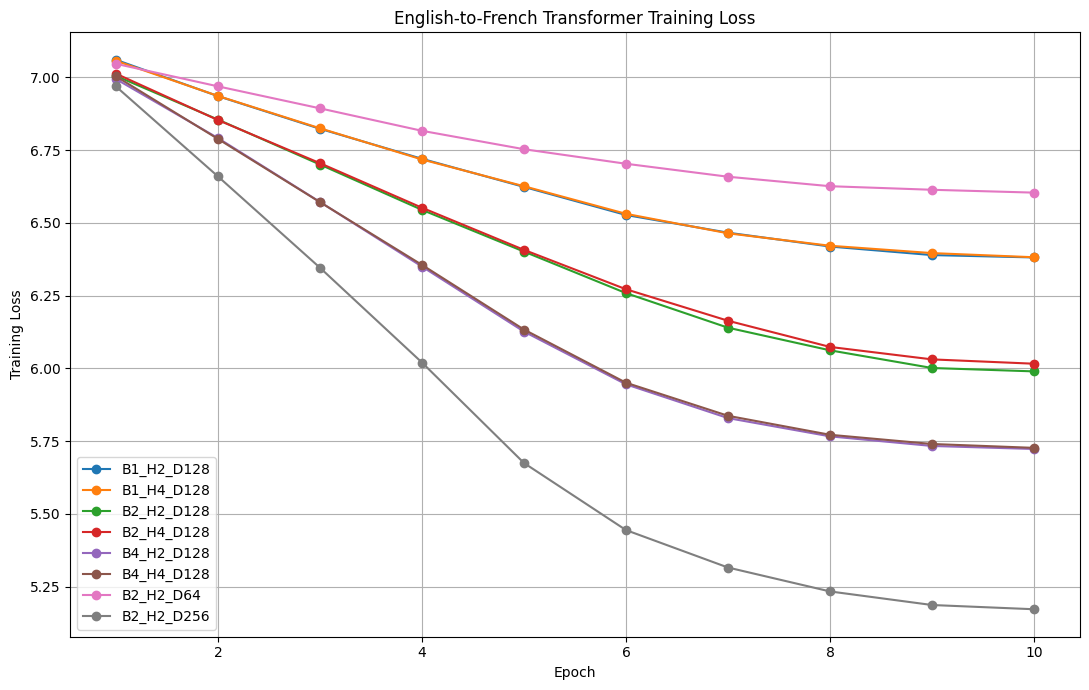

In [29]:
plt.figure(figsize=(11, 7))

for configuration in TRANSFORMER_CONFIGURATIONS:
    name = configuration["name"]

    history = problem3_experiments[
        name
    ]["history"]

    epochs = range(
        1,
        len(history["training_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["training_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(
    "English-to-French Transformer Training Loss"
)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "problem3_training_loss_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

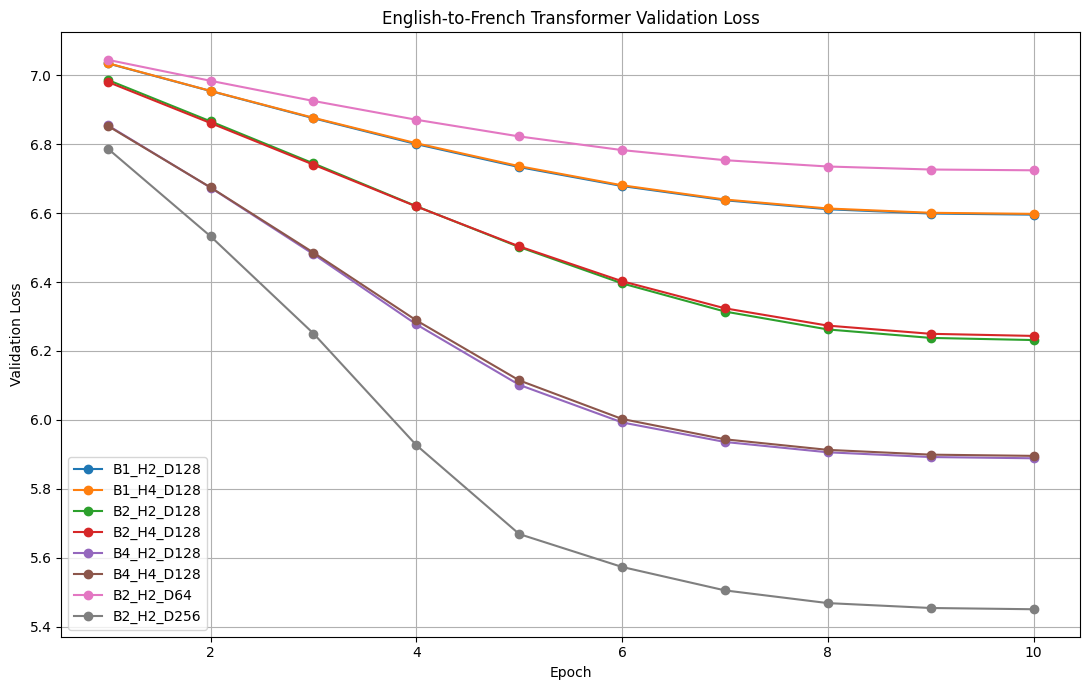

In [30]:
plt.figure(figsize=(11, 7))

for configuration in TRANSFORMER_CONFIGURATIONS:
    name = configuration["name"]

    history = problem3_experiments[
        name
    ]["history"]

    epochs = range(
        1,
        len(history["validation_loss"]) + 1
    )

    plt.plot(
        epochs,
        history["validation_loss"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title(
    "English-to-French Transformer Validation Loss"
)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "problem3_validation_loss_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

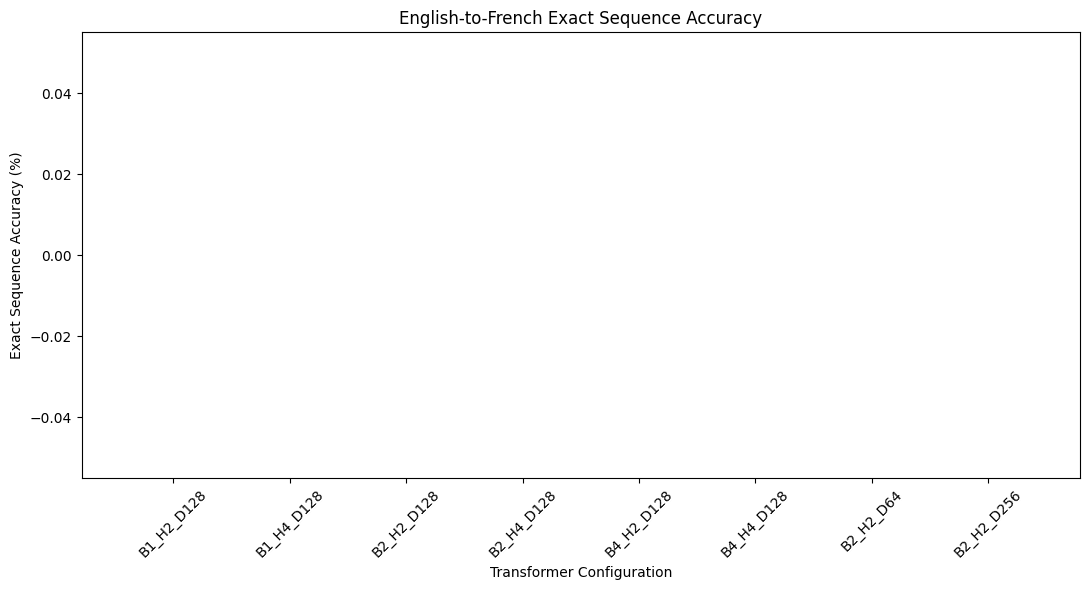

In [31]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem3_results["Configuration"],
    problem3_results["Sequence Accuracy (%)"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Exact Sequence Accuracy (%)")
plt.title(
    "English-to-French Exact Sequence Accuracy"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem3_sequence_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

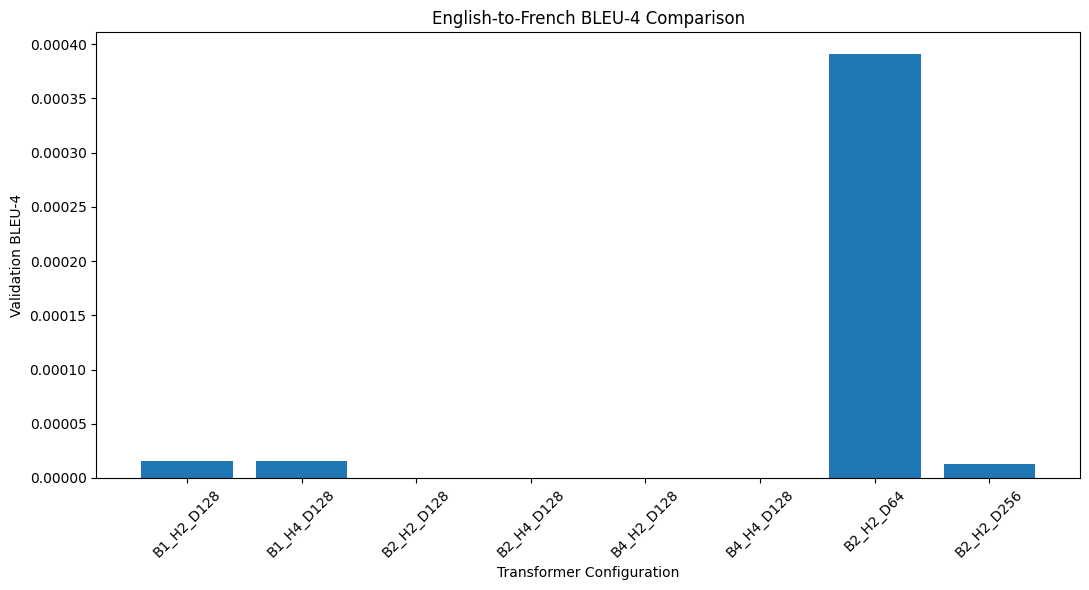

In [32]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem3_results["Configuration"],
    problem3_results["Validation BLEU-4"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Validation BLEU-4")
plt.title(
    "English-to-French BLEU-4 Comparison"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem3_bleu4_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

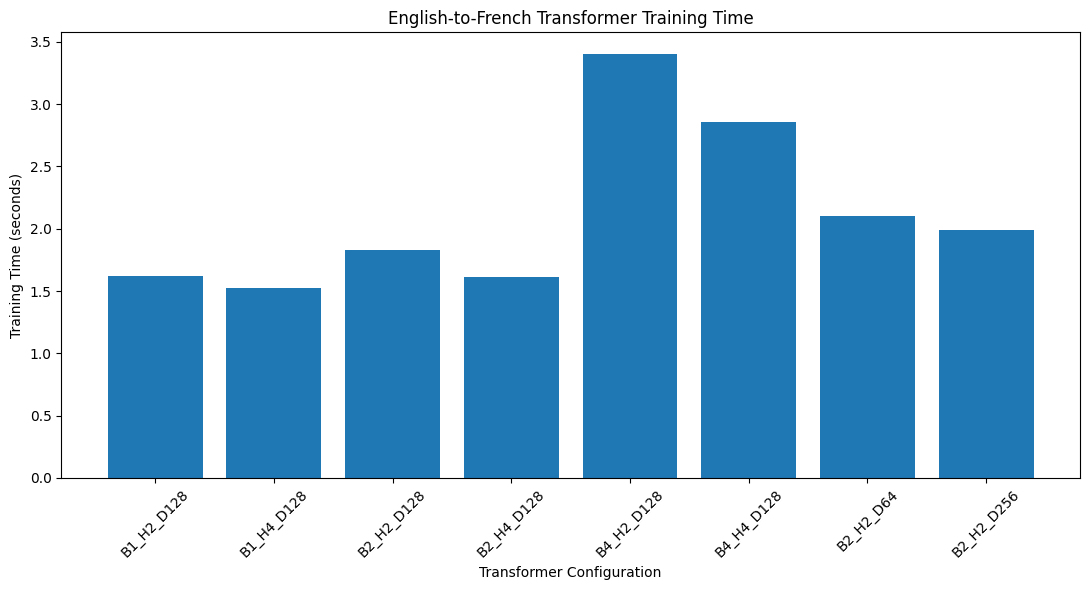

In [33]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem3_results["Configuration"],
    problem3_results["Training Time (s)"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Training Time (seconds)")
plt.title(
    "English-to-French Transformer Training Time"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem3_training_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

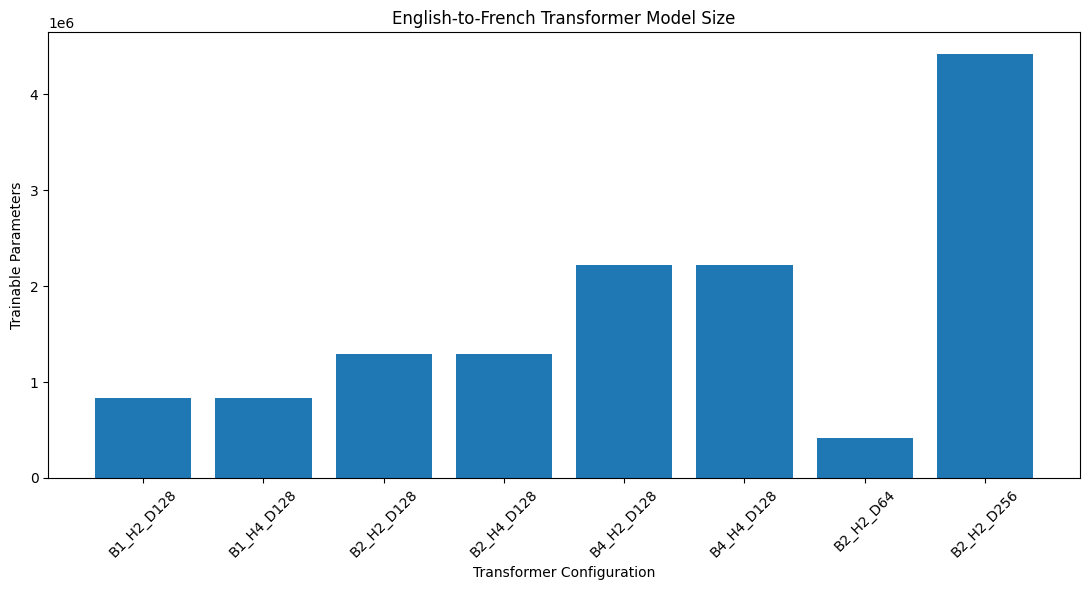

In [34]:
plt.figure(figsize=(11, 6))

plt.bar(
    problem3_results["Configuration"],
    problem3_results["Parameters"]
)

plt.xlabel("Transformer Configuration")
plt.ylabel("Trainable Parameters")
plt.title(
    "English-to-French Transformer Model Size"
)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "problem3_parameter_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
best_configuration_name = (
    ranked_problem3_results.loc[
        0,
        "Configuration"
    ]
)

best_configuration = next(
    configuration
    for configuration in TRANSFORMER_CONFIGURATIONS
    if configuration["name"]
    == best_configuration_name
)

best_checkpoint = (
    ranked_problem3_results.loc[
        0,
        "Checkpoint"
    ]
)

best_model = TranslationTransformer(
    source_vocabulary_size=ENGLISH_VOCABULARY_SIZE,
    target_vocabulary_size=FRENCH_VOCABULARY_SIZE,
    source_padding_index=ENGLISH_PAD_INDEX,
    target_padding_index=FRENCH_PAD_INDEX,
    d_model=best_configuration["d_model"],
    number_of_heads=best_configuration[
        "number_of_heads"
    ],
    number_of_layers=best_configuration[
        "number_of_layers"
    ],
    feedforward_size=best_configuration[
        "feedforward_size"
    ],
    dropout=DROPOUT,
    maximum_source_length=MAX_ENGLISH_LENGTH,
    maximum_target_length=MAX_FRENCH_LENGTH
).to(device)

best_model.load_state_dict(
    torch.load(
        best_checkpoint,
        map_location=device
    )
)

best_model.eval()

print("Best configuration:", best_configuration_name)
print("Loaded checkpoint:", best_checkpoint)

Best configuration: B2_H2_D64
Loaded checkpoint: problem3_B2_H2_D64_best.pt


In [36]:
@torch.no_grad()
def translate_english_to_french(
    model,
    english_sentence
):
    source_encoded = encode_sentence(
        english_sentence,
        english_token_to_index,
        MAX_ENGLISH_LENGTH
    )

    source_tensor = torch.tensor(
        source_encoded,
        dtype=torch.long,
        device=device
    ).unsqueeze(0)

    generated_indices = greedy_decode_batch(
        model=model,
        source_tokens=source_tensor,
        maximum_target_length=MAX_FRENCH_LENGTH
    )[0].cpu()

    generated_tokens = clean_token_indices(
        generated_indices,
        french_index_to_token
    )

    return detokenize(generated_tokens)


example_translation = (
    translate_english_to_french(
        best_model,
        validation_pairs[0][0]
    )
)

print(
    "English:",
    validation_pairs[0][0]
)

print(
    "Reference French:",
    validation_pairs[0][1]
)

print(
    "Generated French:",
    example_translation
)

English: She won a tennis match
Reference French: Elle a gagné un match de tennis
Generated French: elle romans traditionnels nouvel faire terminé télévision traverser fort les fort


In [37]:
def create_qualitative_examples(
    model,
    number_of_examples=10
):
    smoothing = SmoothingFunction().method1

    selected_indices = np.linspace(
        0,
        len(validation_pairs) - 1,
        number_of_examples,
        dtype=int
    )

    rows = []

    for validation_index in selected_indices:
        english_sentence, reference_french = (
            validation_pairs[
                validation_index
            ]
        )

        generated_french = (
            translate_english_to_french(
                model,
                english_sentence
            )
        )

        reference_tokens = tokenize(
            reference_french
        )

        generated_tokens = tokenize(
            generated_french
        )

        exact_match = (
            generated_tokens
            == reference_tokens
        )

        individual_bleu_4 = sentence_bleu(
            [reference_tokens],
            generated_tokens,
            weights=(0.25, 0.25, 0.25, 0.25),
            smoothing_function=smoothing
        )

        rows.append({
            "English Input": english_sentence,
            "Reference French": reference_french,
            "Generated French": generated_french,
            "Exact Match": exact_match,
            "Sentence BLEU-4": individual_bleu_4
        })

    return pd.DataFrame(rows)


qualitative_results = create_qualitative_examples(
    best_model,
    number_of_examples=10
)

pd.set_option(
    "display.max_colwidth",
    300
)

qualitative_results

,English Input,Reference French,Generated French,Exact Match,Sentence BLEU-4
0,She won a tennis match,Elle a gagné un match de tennis,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.01885
1,He drives a black sedan,Il conduit une berline noire,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.00000
2,The library is a quiet place,La bibliothèque est un endroit calme,elle romans avancés t'appellerai terminé télévision traverser fort les fort décidé,False,0.00000
3,The dog barks loudly,Le chien aboie bruyamment,elle romans traditionnels nouvel faire terminé télévision traverser fort les,False,0.00000
4,She won first place in the writing contest,Elle a remporté la première place au concours d'écriture,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.01885
5,She visits her grandparents,Elle visite ses grands-parents,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.01885
6,She paints her room white,Elle peint sa chambre en blanc,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.01885
7,The engine makes a strange noise when starting,Le moteur fait un bruit étrange au démarrage,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.00000
8,The cat climbs the tall tree,Le chat grimpe sur le grand arbre,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.00000
9,We need to buy a dozen fresh eggs,Nous devons acheter une douzaine d'œufs frais,elle romans traditionnels nouvel faire terminé télévision traverser fort les fort,False,0.00000


In [38]:
qualitative_results.to_csv(
    "problem3_qualitative_translations.csv",
    index=False
)

print(
    "Saved: problem3_qualitative_translations.csv"
)

Saved: problem3_qualitative_translations.csv


In [39]:
homework3_rnn_results = pd.DataFrame([
    {
        "Model": "GRU Encoder-Decoder Without Attention",
        "Training Loss": 1.9493,
        "Validation Loss": 5.3307,
        "Sequence Accuracy (%)": 0.00,
        "Validation BLEU-4": 0.0696,
        "Training Time (s)": "Not recorded",
        "Parameters": 3360227,
        "Model Size (MB)": 12.818
    },
    {
        "Model": "GRU Encoder-Decoder With Attention",
        "Training Loss": 0.2010,
        "Validation Loss": 5.7968,
        "Sequence Accuracy (%)": 0.00,
        "Validation BLEU-4": 0.1181,
        "Training Time (s)": "Not recorded",
        "Parameters": 5436131,
        "Model Size (MB)": 20.737
    }
])

homework3_rnn_results

,Model,Training Loss,Validation Loss,Sequence Accuracy (%),Validation BLEU-4,Training Time (s),Parameters,Model Size (MB)
0,GRU Encoder-Decoder Without Attention,1.9493,5.3307,0.0,0.0696,Not recorded,3360227,12.818
1,GRU Encoder-Decoder With Attention,0.2010,5.7968,0.0,0.1181,Not recorded,5436131,20.737


In [40]:
best_transformer_result = (
    ranked_problem3_results.iloc[0]
)

best_transformer_comparison_row = pd.DataFrame([
    {
        "Model": (
            "Transformer "
            + best_transformer_result[
                "Configuration"
            ]
        ),
        "Training Loss": best_transformer_result[
            "Training Loss"
        ],
        "Validation Loss": best_transformer_result[
            "Validation Loss"
        ],
        "Sequence Accuracy (%)": (
            best_transformer_result[
                "Sequence Accuracy (%)"
            ]
        ),
        "Validation BLEU-4": (
            best_transformer_result[
                "Validation BLEU-4"
            ]
        ),
        "Training Time (s)": (
            best_transformer_result[
                "Training Time (s)"
            ]
        ),
        "Parameters": best_transformer_result[
            "Parameters"
        ],
        "Model Size (MB)": (
            best_transformer_result[
                "Model Size (MB)"
            ]
        )
    }
])

transformer_vs_rnn = pd.concat(
    [
        homework3_rnn_results,
        best_transformer_comparison_row
    ],
    ignore_index=True
)

transformer_vs_rnn.round({
    "Training Loss": 4,
    "Validation Loss": 4,
    "Sequence Accuracy (%)": 2,
    "Validation BLEU-4": 4,
    "Training Time (s)": 2,
    "Model Size (MB)": 3
})

,Model,Training Loss,Validation Loss,Sequence Accuracy (%),Validation BLEU-4,Training Time (s),Parameters,Model Size (MB)
0,GRU Encoder-Decoder Without Attention,1.9493,5.3307,0.0,0.0696,Not recorded,3360227,12.818
1,GRU Encoder-Decoder With Attention,0.2010,5.7968,0.0,0.1181,Not recorded,5436131,20.737
2,Transformer B2_H2_D64,6.6041,6.7247,0.0,0.0004,2.100834,419170,1.630


In [41]:
transformer_vs_rnn.to_csv(
    "problem3_transformer_vs_rnn.csv",
    index=False
)

print("Saved: problem3_transformer_vs_rnn.csv")

Saved: problem3_transformer_vs_rnn.csv


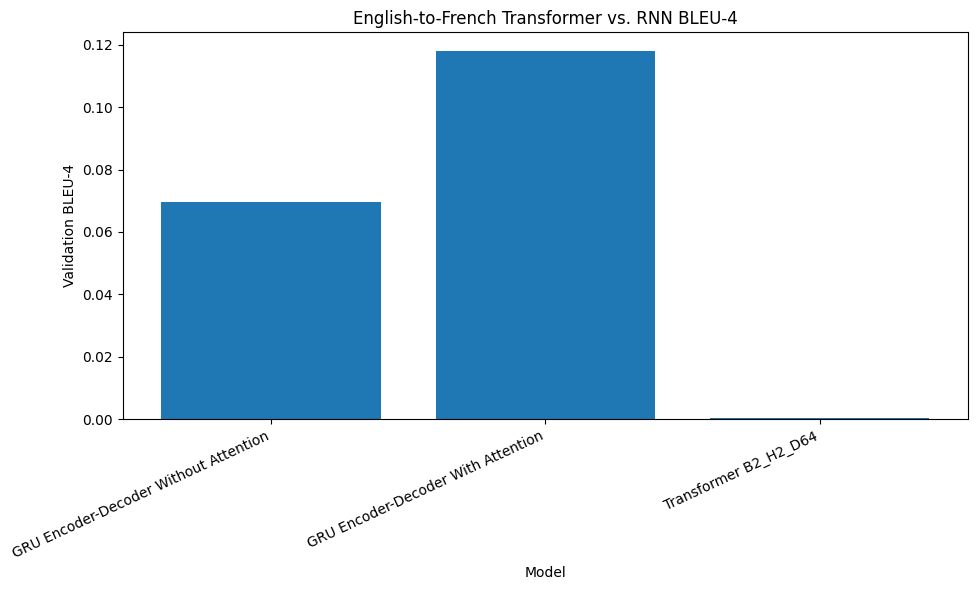

In [42]:
plt.figure(figsize=(10, 6))

plt.bar(
    transformer_vs_rnn["Model"],
    transformer_vs_rnn["Validation BLEU-4"]
)

plt.xlabel("Model")
plt.ylabel("Validation BLEU-4")
plt.title(
    "English-to-French Transformer vs. RNN BLEU-4"
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    "problem3_transformer_vs_rnn_bleu.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

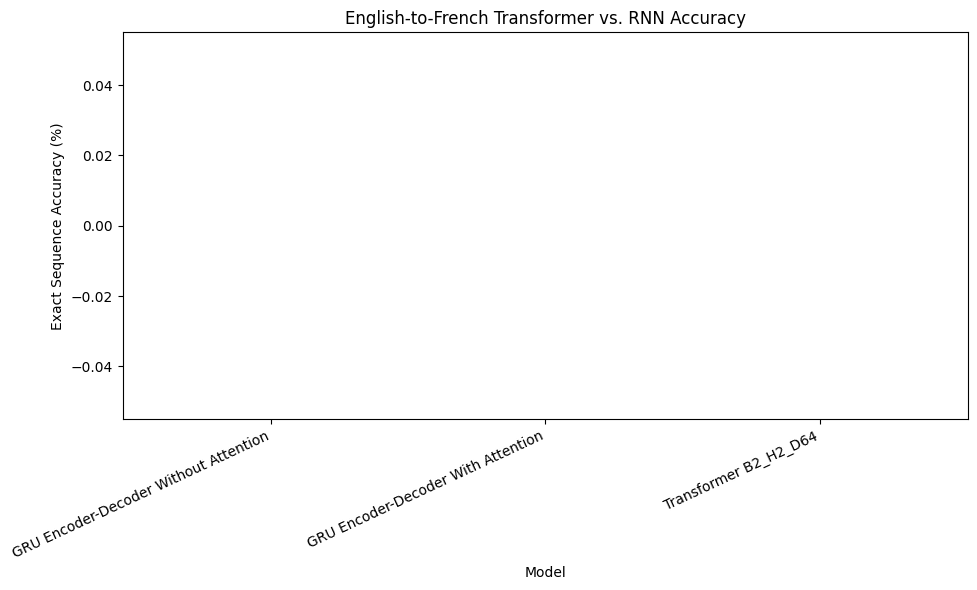

In [43]:
plt.figure(figsize=(10, 6))

plt.bar(
    transformer_vs_rnn["Model"],
    transformer_vs_rnn[
        "Sequence Accuracy (%)"
    ]
)

plt.xlabel("Model")
plt.ylabel("Exact Sequence Accuracy (%)")
plt.title(
    "English-to-French Transformer vs. RNN Accuracy"
)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    "problem3_transformer_vs_rnn_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
preprocessing_information = {
    "seed": SEED,
    "split_seed": SPLIT_SEED,
    "lowercase": LOWERCASE,
    "minimum_frequency": MIN_FREQUENCY,
    "maximum_english_vocabulary": (
        MAX_ENGLISH_VOCABULARY
    ),
    "maximum_french_vocabulary": (
        MAX_FRENCH_VOCABULARY
    ),
    "english_vocabulary_size": (
        ENGLISH_VOCABULARY_SIZE
    ),
    "french_vocabulary_size": (
        FRENCH_VOCABULARY_SIZE
    ),
    "maximum_english_length": (
        MAX_ENGLISH_LENGTH
    ),
    "maximum_french_length": (
        MAX_FRENCH_LENGTH
    ),
    "training_pairs": len(train_pairs),
    "validation_pairs": len(validation_pairs)
}

with open(
    "problem3_preprocessing_information.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        preprocessing_information,
        file,
        indent=4
    )

print(
    "Saved: problem3_preprocessing_information.json"
)

Saved: problem3_preprocessing_information.json


In [45]:
import shutil

os.makedirs(
    "problem3_results",
    exist_ok=True
)

result_extensions = (
    ".csv",
    ".png",
    ".json",
    ".npy"
)

for filename in os.listdir("/content"):
    if (
        filename.startswith("problem3_")
        or filename.startswith("homework4_")
    ):
        if filename.endswith(result_extensions):
            source_path = os.path.join(
                "/content",
                filename
            )

            destination_path = os.path.join(
                "/content/problem3_results",
                filename
            )

            shutil.copy(
                source_path,
                destination_path
            )

shutil.make_archive(
    "/content/problem3_results",
    "zip",
    "/content/problem3_results"
)

print("Created: problem3_results.zip")

Created: problem3_results.zip


In [46]:
from google.colab import files

files.download(
    "/content/problem3_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>